In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # Standard weights and bias
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        
        # Learnable gate scores
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        
        # Initialization
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.constant_(self.bias, 0)
        nn.init.constant_(self.gate_scores, 1.0) # Start with gates open

    def forward(self, x):
        # Sigmoid to constrain gates between 0 and 1
        gates = torch.sigmoid(self.gate_scores)
        
        # Element-wise multiplication for pruning
        pruned_weights = self.weight * gates
        
        return nn.functional.linear(x, pruned_weights, self.bias)

In [4]:
class PruningNet(nn.Module):
    def __init__(self):
        super(PruningNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_gates(self):
        # Helper to collect all gate values for loss calculation and reporting
        all_gates = [
            torch.sigmoid(self.fc1.gate_scores),
            torch.sigmoid(self.fc2.gate_scores),
            torch.sigmoid(self.fc3.gate_scores)
        ]
        return all_gates

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

100%|██████████| 170M/170M [00:12<00:00, 13.6MB/s] 


In [13]:
def train_and_evaluate(lambd, epochs=10):
    model = PruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    pbar = tqdm(range(epochs), desc=f"Lambda {lambd}")
    for epoch in pbar: 
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            class_loss = criterion(outputs, labels)
            gates_list = model.get_gates()
            sparsity_loss = sum([torch.sum(g) for g in gates_list])
            
            total_loss = class_loss + lambd * sparsity_loss
            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()

        # 3. Update the display info
        pbar.set_postfix({'avg_loss': f"{running_loss/len(trainloader):.4f}"})
            
    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    
    # Calculate Sparsity
    all_gate_values = torch.cat([g.flatten() for g in model.get_gates()])
    pruned_count = (all_gate_values < 1e-2).sum().item()
    total_weights = all_gate_values.numel()
    sparsity_pct = 100 * pruned_count / total_weights
    
    return model, accuracy, sparsity_pct, all_gate_values.detach().cpu().numpy()

In [14]:
lambdas = [1e-6, 1e-5, 1e-4]
results = []
models = {}

for l in lambdas:
    print(f"Training with Lambda: {l}...")
    model, acc, spark, final_gates = train_and_evaluate(l)
    results.append({"Lambda": l, "Test Accuracy": f"{acc:.2f}%", "Sparsity Level (%)": f"{spark:.2f}%"})
    models[l] = (model, final_gates)

Training with Lambda: 1e-06...


Lambda 1e-06:   0%|          | 0/10 [00:00<?, ?it/s]

Training with Lambda: 1e-05...


Lambda 1e-05:   0%|          | 0/10 [00:00<?, ?it/s]

Training with Lambda: 0.0001...


Lambda 0.0001:   0%|          | 0/10 [00:00<?, ?it/s]


Summary of Results:
     Lambda Test Accuracy Sparsity Level (%)
0  0.000001        54.70%              0.00%
1  0.000010        55.81%              0.00%
2  0.000100        56.65%              0.00%


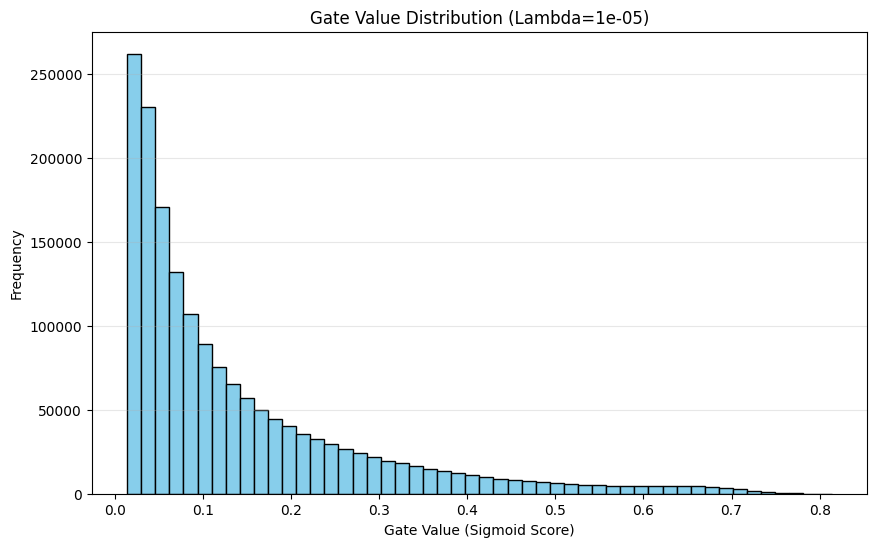


Best model saved as self_pruning_model.pth


In [15]:
# 1. Summary Table
df = pd.DataFrame(results)
print("\nSummary of Results:")
print(df)

# 2. Gate Distribution Plot for the "Medium" Lambda (often the best balance)
best_lambda = lambdas[1] 
_, gate_dist = models[best_lambda]

plt.figure(figsize=(10, 6))
plt.hist(gate_dist, bins=50, color='skyblue', edgecolor='black')
plt.title(f"Gate Value Distribution (Lambda={best_lambda})")
plt.xlabel("Gate Value (Sigmoid Score)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Output the model
best_model = models[best_lambda][0]
torch.save(best_model.state_dict(), "self_pruning_model.pth")
print("\nBest model saved as self_pruning_model.pth")